Question 3

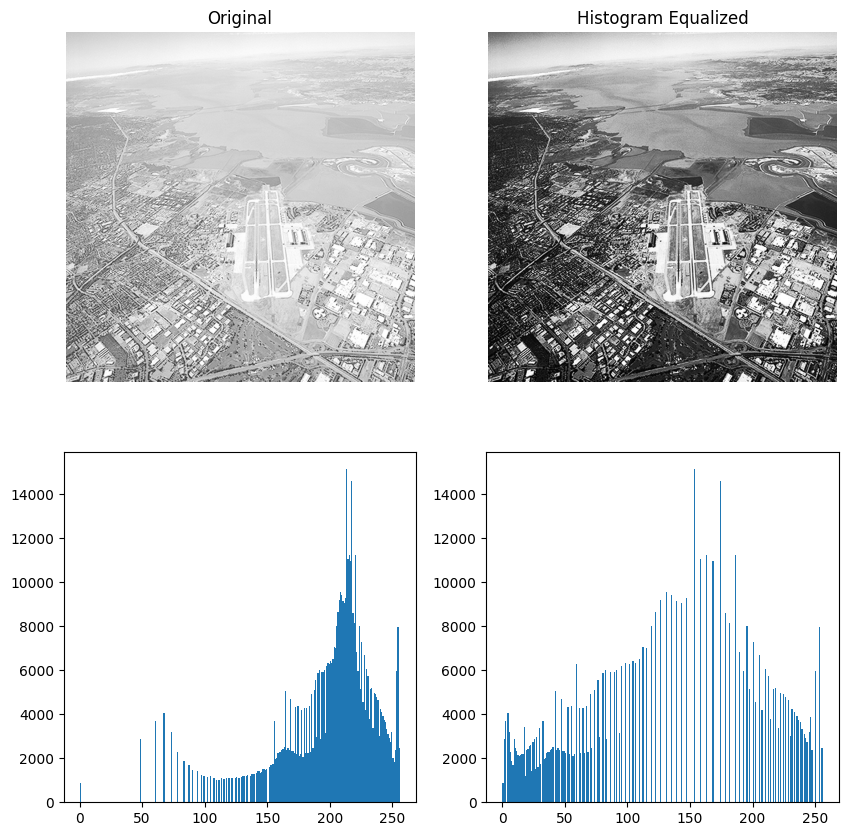

In [1]:
import cv2 as cv
import numpy as np
import sys
import matplotlib.pyplot as plt

img = cv.imread('runway.png')
if img is None:
    print("Could not read input image")
    sys.exit(1)

img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Do histogram equalization
flat_img = img.flatten()

hist = np.bincount(flat_img, minlength=256)
cdf = hist.cumsum()

cdf_min = cdf[cdf > 0].min()
total_pixels = flat_img.size

cdf_normalized = (cdf - cdf_min) / (total_pixels - cdf_min) * 255
cdf_normalized = cdf_normalized.astype(np.uint8)

img_eq = cdf_normalized[img]

#display iamges and histogram
plot, axis = plt.subplots(2,2,figsize=(10,10))

axis[0,0].imshow(img,cmap='gray')
axis[0,0].set_title('Original')
axis[0,0].axis('off')

axis[1,0].hist(img.flatten(),bins=256, range=[0,256])

axis[0,1].imshow(img_eq,cmap='gray')
axis[0,1].set_title('Histogram Equalized')
axis[0,1].axis('off')

axis[1,1].hist(img_eq.flatten(), bins=256, range=[0,256])
plt.show()
